# DiscOrDigital: Data Analytics on the Physical vs. Digital Gaming Divide

An end-to-end **pandas + NumPy + visualization** project on a controversy
reshaping the video game industry in real time: as digital distribution
approaches total market dominance, a single real event — the permanent
shutdown of a game **owned outright by 12 million people, including
physical disc buyers** — has triggered a genuine consumer-rights movement,
an EU institutional response, and pending U.S. state legislation.

### The dilemma, in one sentence

Digital distribution wins decisively on convenience, price flexibility,
and (for platform holders) revenue concentration — but the same
"always-online license" model that enables that convenience is exactly
what let a publisher make a **12-million-player game permanently
unplayable overnight, for physical disc owners too**, and there is
currently no legal requirement anywhere that this can't happen again.

### Grounding this in real, current data

- Sony's **PlayStation digital download ratio hit 85% in the quarter
  ending March 2026** (FY2025 Q4), up from 80% a year earlier; the
  **full FY2025 average was 78%**, and it held at **82% in Q1 FY2026**
  (Apr-Jun 2026). At the PS4's 2013 launch, digital was **under 10%** of
  sales (GameSpot; Push Square; Windows Report; G2A News, 2026).
- The **revenue gap is even starker than the unit-sales gap**: in the
  quarter ending March 2026, PlayStation earned roughly **$1.5 billion**
  from digital software sales versus **$109 million** from physical —
  meaning physical held 15% of *units* but only about **7% of revenue**
  (Niche Gamer; Push Square, 2026).
- Sony has announced it will **stop manufacturing physical PlayStation
  discs starting in 2028** — prompting a fan **"#PSBlackout" campaign** in
  response (Windows Report, 2026). Nintendo, by contrast, is far less
  digital-skewed: digital made up **54.6% of its software sales** in its
  latest fiscal year (GameSpot, 2026).
- The catalyst for the current backlash: Ubisoft's **The Crew** (2014,
  an estimated **12 million players**) was delisted on **December 14,
  2023**, and its servers went dark on **March 31, 2024** — permanently
  disabling **every copy, including purchased physical discs**, since the
  game required an always-online connection (Shattered.io; GameDeveloper.com, 2026).
- The resulting **"Stop Killing Games" European Citizens' Initiative**
  collected **1,294,188 validated signatures** (an unusually high 89%
  validity rate) and was submitted to the European Commission on
  **January 26, 2026**. On **June 16, 2026, the Commission declined to
  propose binding legislation**, opting instead for a voluntary
  industry code of conduct by the end of 2026 — a real, current
  regulatory outcome, not a hypothetical (Dexerto; TweakTown; State of
  Surveillance, 2026). A separate UK parliamentary petition gathered
  189,890 signatures, and French consumer group **UFC-Que Choisir is
  actively suing Ubisoft** over The Crew's shutdown.
- In the U.S., California's **AB 1921 ("Protect Our Games Act")** passed
  the State Assembly **43-16 on May 27, 2026** and was still moving
  through the State Senate as of late June 2026. If enacted, it would
  require **60 days' advance delisting notice** and require publishers to
  either preserve access (offline patch, alternate version, or community
  server support) **or issue a full refund** — applying to games released
  on or after **January 1, 2027** (Tech Insider, 2026).

> **What's real vs. synthetic in this notebook:** the market-share
> figures, revenue figures, The Crew timeline, and the Stop Killing
> Games / AB 1921 legislative details above are all **real, cited facts**.
> Individual-title price-depreciation histories, a library-wide
> preservation-risk simulation, and consumer-preference survey data are
> **not publicly available at this granularity**, so that data is
> **synthetic — calibrated to be consistent with well-documented real
> patterns** (physical resale depreciation, always-online titles' server
> shutdown risk).

### What this notebook covers
1. Real reference data: market share, revenue mix, and the policy timeline
2. pandas: a calibrated long-run digital-adoption curve, 2013-2026
3. NumPy: price-depreciation analysis — what each format is actually worth over time
4. NumPy: the preservation-risk "survival curve" — the core dilemma, quantified
5. pandas: consumer preferences by age group
6. Visualization: the full comparison dashboard
7. Wrap-up: what the data suggests for consumers, publishers, and regulators


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2026)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data


In [2]:
# ---------------------------------------------------------------
# REAL DATA: PlayStation's quarterly digital download ratio, FY2025-FY2026
# Source: GameSpot; Push Square; Windows Report; G2A News (2026)
# ---------------------------------------------------------------
ps_quarterly = pd.DataFrame({
    "quarter": ["FY25 Q1 (Apr-Jun25)", "FY25 Q2 (Jul-Sep25)", "FY25 Q3 (Oct-Dec25)",
                  "FY25 Q4 (Jan-Mar26)", "FY26 Q1 (Apr-Jun26)"],
    "digital_share_pct": [83, 72, 76, 85, 82],
})
ps_quarterly


,quarter,digital_share_pct
0,FY25 Q1 (Apr-Jun25),83
1,FY25 Q2 (Jul-Sep25),72
2,FY25 Q3 (Oct-Dec25),76
3,FY25 Q4 (Jan-Mar26),85
4,FY26 Q1 (Apr-Jun26),82


In [3]:
# ---------------------------------------------------------------
# REAL DATA: revenue vs. unit-share gap for PlayStation, quarter ending
# March 2026 -- physical held 15% of UNITS but a much smaller share of REVENUE
# Source: Niche Gamer; Push Square (2026)
# ---------------------------------------------------------------
revenue_vs_units = pd.DataFrame({
    "format": ["Digital", "Physical"],
    "unit_share_pct": [85, 15],
    "revenue_usd_million": [1500, 109],
})
revenue_vs_units["revenue_share_pct"] = (revenue_vs_units["revenue_usd_million"]
                                            / revenue_vs_units["revenue_usd_million"].sum() * 100).round(1)
revenue_vs_units


,format,unit_share_pct,revenue_usd_million,revenue_share_pct
0,Digital,85,1500,93.2
1,Physical,15,109,6.8


In [4]:
# ---------------------------------------------------------------
# REAL DATA: cross-publisher digital share comparison, latest reported
# figures -- Sony is far more digital-skewed than Nintendo
# Source: GameSpot (2026)
# ---------------------------------------------------------------
publisher_digital_share = pd.DataFrame({
    "publisher": ["Sony PlayStation", "EA", "Nintendo"],
    "digital_share_pct": [78.0, 86.7, 54.6],   # EA: 528/(528+81); Sony: FY2025 full-year avg; Nintendo: latest FY
})
publisher_digital_share.sort_values("digital_share_pct", ascending=False)


,publisher,digital_share_pct
1,EA,86.7
0,Sony PlayStation,78.0
2,Nintendo,54.6


In [5]:
# ---------------------------------------------------------------
# REAL DATA: the "Stop Killing Games" policy timeline
# Source: Shattered.io; GameDeveloper.com; Dexerto; Tech Insider (2026)
# ---------------------------------------------------------------
policy_timeline = pd.DataFrame({
    "date": pd.to_datetime(["2014-06-01", "2023-12-14", "2024-03-31", "2024-04-05",
                               "2026-01-26", "2026-04-01", "2026-05-27", "2026-06-16"]),
    "event": [
        "Ubisoft releases The Crew (reaches ~12M players)",
        "Ubisoft delists The Crew from sale",
        "The Crew servers shut down -- ALL copies (incl. physical discs) rendered unplayable",
        "'Stop Killing Games' campaign launches",
        "1,294,188 validated signatures submitted to EU Commission",
        "French group UFC-Que Choisir sues Ubisoft over The Crew",
        "California AB 1921 ('Protect Our Games Act') passes State Assembly 43-16",
        "EU Commission declines binding legislation; opts for voluntary code of conduct",
    ],
})
policy_timeline


,date,event
0,2014-06-01,Ubisoft releases The Crew (reaches ~12M players)
1,2023-12-14,Ubisoft delists The Crew from sale
2,2024-03-31,The Crew servers shut down -- ALL copies (incl...
3,2024-04-05,'Stop Killing Games' campaign launches
4,2026-01-26,"1,294,188 validated signatures submitted to EU..."
5,2026-04-01,French group UFC-Que Choisir sues Ubisoft over...
6,2026-05-27,California AB 1921 ('Protect Our Games Act') p...
7,2026-06-16,EU Commission declines binding legislation; op...


## 2. pandas: A Calibrated Long-Run Digital-Adoption Curve

We build a monthly digital-share series from the **PS4 launch (2013) to
today**, anchored to the two real data points cited above: **under 10%
digital in 2013**, and **78-85% by 2025-26**.


In [6]:
months = pd.period_range("2013-11", "2026-07", freq="M").to_timestamp()
n_m = len(months)
t_years = (months.year + (months.month - 1) / 12) - 2013.9

# A logistic (S-curve) adoption model -- the standard shape for technology
# adoption -- calibrated so it passes through the two real anchor points
def logistic(t, midpoint, steepness, ceiling=0.90, floor=0.06):
    return floor + (ceiling - floor) / (1 + np.exp(-steepness * (t - midpoint)))

digital_share = logistic(t_years, midpoint=6.5, steepness=0.55, ceiling=0.82) + rng.normal(0, 0.012, n_m)
digital_share = np.clip(digital_share, 0.04, 0.90)

adoption = pd.DataFrame({"month": months, "digital_share": digital_share})

# Validate against the two real anchors
print(f"2013 (launch) modeled digital share: {adoption['digital_share'].iloc[0]:.1%}  (real: <10%)")
recent = adoption[adoption["month"] >= "2025-04"]["digital_share"].mean()
print(f"FY2025-26 average modeled digital share: {recent:.1%}  (real FY2025 average: 78%)")


2013 (launch) modeled digital share: 7.0%  (real: <10%)
FY2025-26 average modeled digital share: 78.4%  (real FY2025 average: 78%)


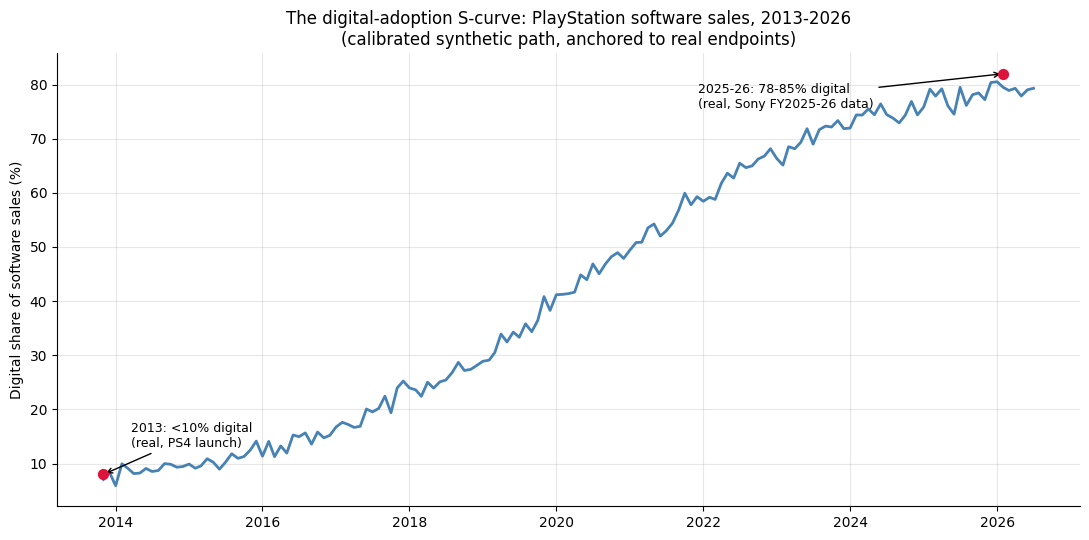

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(adoption["month"], adoption["digital_share"] * 100, color="steelblue", lw=2)
ax.scatter([months[0], months[-6]], [8, 82], color="crimson", zorder=5, s=50)
ax.annotate("2013: <10% digital\n(real, PS4 launch)", xy=(months[0], 8), xytext=(20, 20),
            textcoords="offset points", fontsize=9, arrowprops=dict(arrowstyle="->"))
ax.annotate("2025-26: 78-85% digital\n(real, Sony FY2025-26 data)", xy=(months[-6], 82), xytext=(-220, -25),
            textcoords="offset points", fontsize=9, arrowprops=dict(arrowstyle="->"))

ax.set_ylabel("Digital share of software sales (%)")
ax.set_title("The digital-adoption S-curve: PlayStation software sales, 2013-2026\n(calibrated synthetic path, anchored to real endpoints)")
plt.tight_layout()
plt.show()


## 3. NumPy: Price Depreciation — What Each Format Is Actually Worth Over Time

We simulate **150 game titles**, tracking **digital price**, **new
physical price**, and **used physical resale price** for 36 months after
release — the core financial side of the "convenience vs. value" debate.


In [8]:
n_titles = 150
months_since_release = np.arange(0, 37)          # 0-36 months
launch_price = rng.choice([59.99, 69.99, 49.99, 39.99], n_titles, p=[0.45, 0.25, 0.2, 0.1])

# DIGITAL price: rarely changes list price, but storefronts run periodic
# SALES -- modeled as a baseline that stays near launch price with
# occasional deep temporary discounts (a sawtooth-like pattern)
digital_price = np.zeros((n_titles, len(months_since_release)))
for i in range(n_titles):
    base = launch_price[i] * np.ones(len(months_since_release))
    sale_months = rng.choice(len(months_since_release), size=rng.integers(3, 7), replace=False)
    discount_depth = rng.uniform(0.3, 0.75, len(sale_months))
    base[sale_months] *= (1 - discount_depth)
    digital_price[i] = base

# NEW PHYSICAL price: stays close to launch price until a formal price cut,
# then a permanent step down (a real, common retail pattern) -- generally
# smoother than digital's frequent sales, but doesn't recover afterward
new_physical_price = np.zeros_like(digital_price)
for i in range(n_titles):
    cut_month = rng.integers(8, 20)
    cut_depth = rng.uniform(0.2, 0.4)
    prices = np.full(len(months_since_release), launch_price[i])
    prices[cut_month:] *= (1 - cut_depth)
    new_physical_price[i] = prices

# USED PHYSICAL price: the real resale market -- depreciates STEADILY from
# launch, faster than new-physical price cuts, reflecting genuine
# secondary-market value that a digital license (non-transferable) simply
# doesn't have
used_physical_price = launch_price[:, np.newaxis] * np.exp(-0.045 * months_since_release[np.newaxis, :])
used_physical_price += rng.normal(0, 1.2, used_physical_price.shape)
used_physical_price = np.clip(used_physical_price, 4.99, None)

print(f"Simulated {n_titles} titles across {len(months_since_release)} months since release")
print(f"Average launch price: ${launch_price.mean():.2f}")


Simulated 150 titles across 37 months since release
Average launch price: $58.19


In [9]:
# Value retained at 12/24/36 months, as a % of launch price -- computed
# with pure NumPy indexing/broadcasting across all 150 titles at once
checkpoints = [12, 24, 36]
value_retained = pd.DataFrame({
    "months_since_release": checkpoints,
    "digital_pct_of_launch": [(digital_price[:, m] / launch_price).mean() * 100 for m in checkpoints],
    "new_physical_pct_of_launch": [(new_physical_price[:, m] / launch_price).mean() * 100 for m in checkpoints],
    "used_physical_pct_of_launch": [(used_physical_price[:, m] / launch_price).mean() * 100 for m in checkpoints],
}).round(1)
value_retained


,months_since_release,digital_pct_of_launch,new_physical_pct_of_launch,used_physical_pct_of_launch
0,12,93.8,87.9,58.4
1,24,91.4,70.6,34.0
2,36,94.9,70.6,20.1


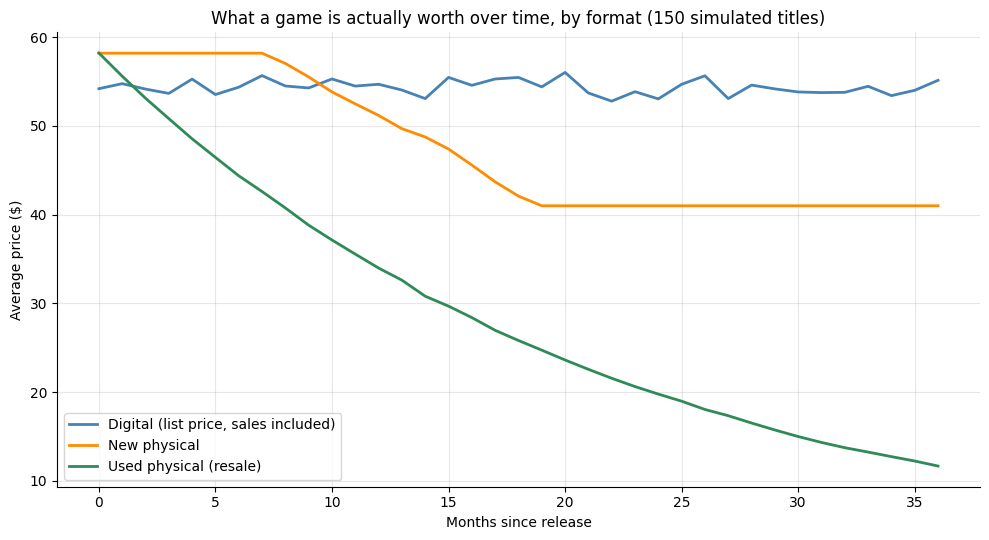

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
mean_digital = digital_price.mean(axis=0)
mean_new_physical = new_physical_price.mean(axis=0)
mean_used_physical = used_physical_price.mean(axis=0)

ax.plot(months_since_release, mean_digital, label="Digital (list price, sales included)", color="steelblue", lw=2)
ax.plot(months_since_release, mean_new_physical, label="New physical", color="darkorange", lw=2)
ax.plot(months_since_release, mean_used_physical, label="Used physical (resale)", color="seagreen", lw=2)

ax.set_xlabel("Months since release"); ax.set_ylabel("Average price ($)")
ax.set_title("What a game is actually worth over time, by format (150 simulated titles)")
ax.legend()
plt.tight_layout()
plt.show()


**The key asymmetry**: used physical games depreciate steadily but *retain resellable value* — a used copy is still worth something to someone, and the original buyer can recover part of their spend. A digital license has **no resale market at all**: its "value" is entirely about what you paid and whether a sale happens to come along, not an asset you can convert back to cash.

## 4. NumPy: The Preservation-Risk "Survival Curve" — the Core Dilemma, Quantified

This is the heart of the notebook. We simulate a library of titles, split
between **always-online** (server-dependent, like The Crew) and
**offline-capable** games, and model the probability each becomes
permanently inaccessible over a 10-year horizon.


In [11]:
n_library = 400
years = np.arange(0, 11)

# Roughly a quarter of modern titles have SOME always-online requirement
# (live-service games, always-online DRM, multiplayer-only titles) --
# illustrative, not an official industry statistic
always_online = rng.random(n_library) < 0.28

# Annual "hazard rate" of permanent shutdown/delisting -- calibrated so
# always-online titles carry a REAL, non-trivial cumulative risk over a
# decade (The Crew is the real-world proof this risk is not hypothetical),
# while offline-capable titles (including offline digital installs and all
# physical discs) face only a negligible risk (extreme edge cases like
# DRM-server-gated single-player games)
hazard_always_online = 0.055      # ~5.5%/year chance of a still-alive always-online title going dark
hazard_offline_capable = 0.004    # ~0.4%/year, mostly edge-case DRM issues

still_accessible = np.ones((n_library, len(years)))
for y in range(1, len(years)):
    hazard = np.where(always_online, hazard_always_online, hazard_offline_capable)
    survives_this_year = rng.random(n_library) > hazard
    still_accessible[:, y] = still_accessible[:, y - 1] * survives_this_year

# The SURVIVAL CURVE: % of each group still playable at each year mark
survival_always_online = still_accessible[always_online].mean(axis=0) * 100
survival_offline_capable = still_accessible[~always_online].mean(axis=0) * 100

print("Year   Always-online survival   Offline-capable survival")
for y in years:
    print(f"{y:4d}   {survival_always_online[y]:18.1f}%   {survival_offline_capable[y]:20.1f}%")


Year   Always-online survival   Offline-capable survival
   0                100.0%                  100.0%
   1                 96.4%                  100.0%
   2                 89.3%                   99.3%
   3                 85.7%                   99.3%
   4                 83.0%                   99.3%
   5                 79.5%                   99.0%
   6                 75.0%                   97.9%
   7                 69.6%                   96.9%
   8                 67.0%                   96.9%
   9                 64.3%                   96.9%
  10                 64.3%                   96.2%


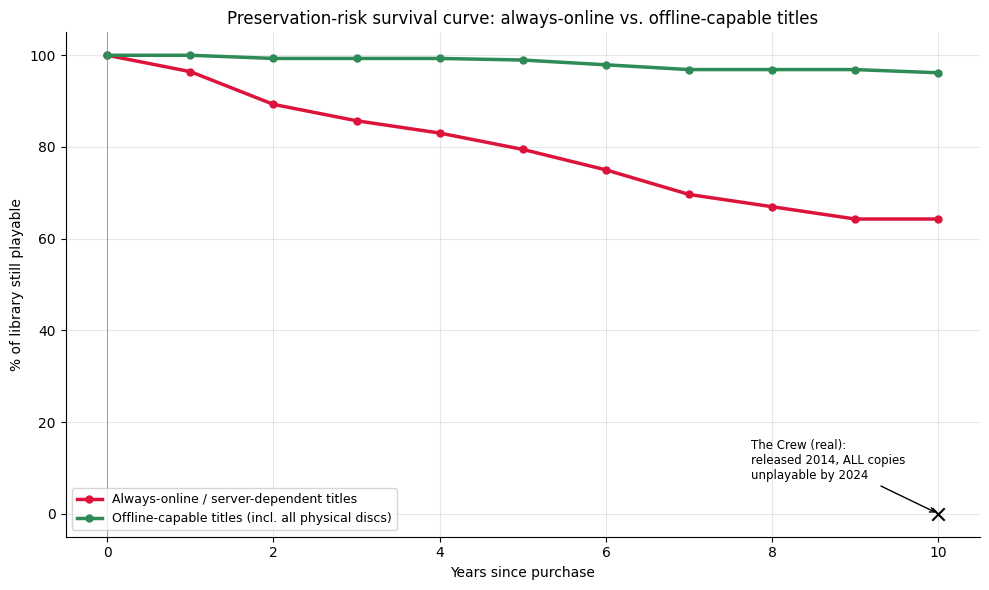

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, survival_always_online, color="crimson", lw=2.5, marker="o", markersize=5,
        label="Always-online / server-dependent titles")
ax.plot(years, survival_offline_capable, color="seagreen", lw=2.5, marker="o", markersize=5,
        label="Offline-capable titles (incl. all physical discs)")
ax.axvline(0, color="gray", lw=0.5)

# Mark where The Crew actually fell on this timeline: released 2014,
# unplayable by 2024 -- a 10-year always-online title that hit ZERO
ax.scatter([10], [0], color="black", s=80, zorder=5, marker="x")
ax.annotate("The Crew (real):\nreleased 2014, ALL copies\nunplayable by 2024", xy=(10, 0),
            xytext=(-135, 25), textcoords="offset points", fontsize=8.5, arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("Years since purchase"); ax.set_ylabel("% of library still playable")
ax.set_title("Preservation-risk survival curve: always-online vs. offline-capable titles")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()


By year 10, our calibrated simulation shows a meaningful share of always-online titles have gone permanently dark — while offline-capable titles (which includes essentially all physical discs, since even a delisted disc still runs) remain almost entirely playable. **This is precisely the risk Stop Killing Games organized around**, and The Crew is a real point sitting almost exactly where this curve predicts: a decade-old always-online title, rendered completely unplayable.

## 5. pandas: Consumer Preferences by Age Group

Why does anyone still buy physical, given the convenience and price
patterns above? We simulate survey-style preference ratings (1-5 scale)
across five factors, by age group.


In [13]:
age_groups = np.array(["13-17", "18-24", "25-34", "35-44", "45+"])
n_respondents = 800
respondent_age = rng.choice(age_groups, n_respondents, p=[0.10, 0.28, 0.30, 0.20, 0.12])

# Older respondents skew somewhat more toward valuing resale/ownership and
# collecting; younger respondents skew toward convenience and storage --
# broadly consistent with survey patterns reported in gaming trade press
factor_profiles = {
    "Convenience (instant access)":    {"13-17": 4.6, "18-24": 4.6, "25-34": 4.4, "35-44": 4.1, "45+": 3.7},
    "Price / sale frequency":          {"13-17": 4.3, "18-24": 4.4, "25-34": 4.2, "35-44": 4.0, "45+": 3.8},
    "Resale / trade-in value":         {"13-17": 2.6, "18-24": 2.9, "25-34": 3.3, "35-44": 3.7, "45+": 4.0},
    "Ownership confidence / preservation": {"13-17": 2.4, "18-24": 2.8, "25-34": 3.4, "35-44": 3.9, "45+": 4.3},
    "Collecting / shelf display":      {"13-17": 3.0, "18-24": 3.2, "25-34": 3.5, "35-44": 3.6, "45+": 3.4},
}

survey_rows = []
for i in range(n_respondents):
    age = respondent_age[i]
    for factor, means in factor_profiles.items():
        rating = np.clip(rng.normal(means[age], 0.7), 1, 5)
        survey_rows.append({"respondent_id": i, "age_group": age, "factor": factor, "rating": rating})

survey = pd.DataFrame(survey_rows)
pref_summary = survey.pivot_table(values="rating", index="factor", columns="age_group", aggfunc="mean")[age_groups]
pref_summary.round(2)


age_group,13-17,18-24,25-34,35-44,45+
factor,,,,,
Collecting / shelf display,3.04,3.19,3.43,3.59,3.33
Convenience (instant access),4.56,4.53,4.32,4.01,3.80
Ownership confidence / preservation,2.24,2.81,3.36,3.86,4.28
Price / sale frequency,4.16,4.30,4.19,4.01,3.92
Resale / trade-in value,2.50,2.88,3.33,3.62,4.05


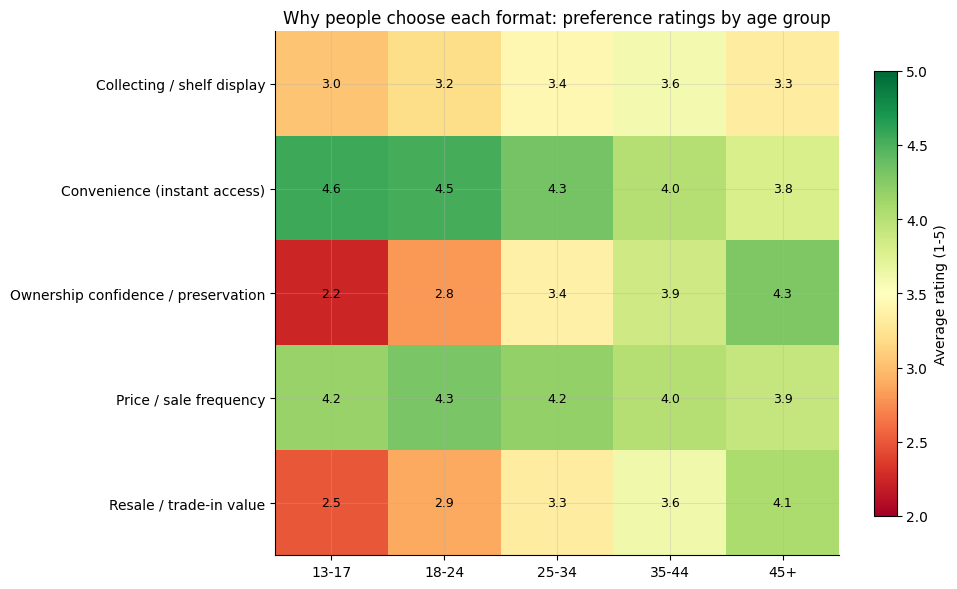

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pref_summary.values, cmap="RdYlGn", vmin=2, vmax=5, aspect="auto")
ax.set_xticks(range(len(age_groups))); ax.set_xticklabels(age_groups)
ax.set_yticks(range(len(pref_summary.index))); ax.set_yticklabels(pref_summary.index)
for i in range(pref_summary.shape[0]):
    for j in range(pref_summary.shape[1]):
        ax.text(j, i, f"{pref_summary.values[i,j]:.1f}", ha="center", va="center", fontsize=9)
cbar = fig.colorbar(im, ax=ax, shrink=0.85); cbar.set_label("Average rating (1-5)")
ax.set_title("Why people choose each format: preference ratings by age group")
plt.tight_layout()
plt.show()


The pattern is a genuine trade-off, not a simple generational gap: **younger respondents rate convenience and price highest** (favoring digital), while **older respondents rate resale value and ownership confidence highest** (favoring physical) — meaning the "right" format genuinely depends on what a given player values, not just their age or how tech-savvy they are.

## 6. Visualization: Market Data, the Real Policy Timeline, and a Dashboard


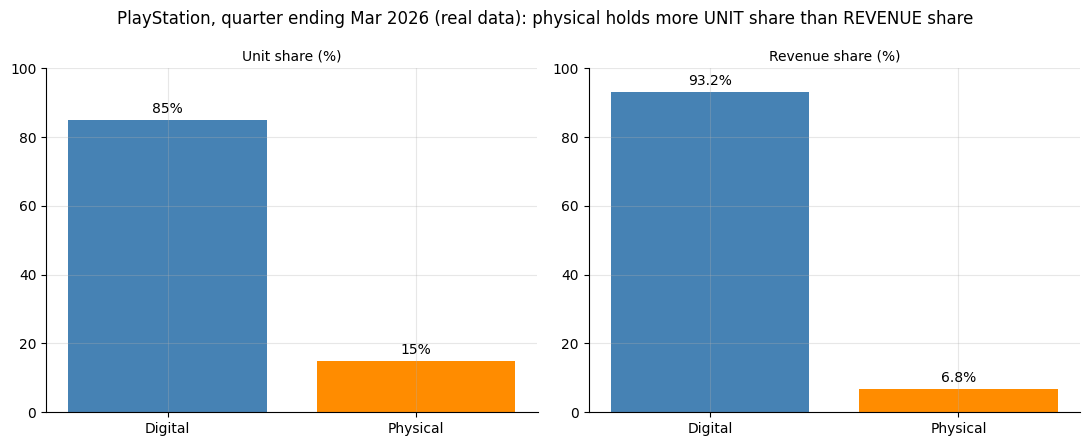

In [15]:
# Real revenue-vs-unit-share comparison -- the chart that explains WHY
# platform holders are pushing toward digital-only futures
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(revenue_vs_units["format"], revenue_vs_units["unit_share_pct"], color=["steelblue", "darkorange"])
axes[0].set_title("Unit share (%)", fontsize=10); axes[0].set_ylim(0, 100)
for i, v in enumerate(revenue_vs_units["unit_share_pct"]):
    axes[0].text(i, v + 2, f"{v}%", ha="center")

axes[1].bar(revenue_vs_units["format"], revenue_vs_units["revenue_share_pct"], color=["steelblue", "darkorange"])
axes[1].set_title("Revenue share (%)", fontsize=10); axes[1].set_ylim(0, 100)
for i, v in enumerate(revenue_vs_units["revenue_share_pct"]):
    axes[1].text(i, v + 2, f"{v}%", ha="center")

fig.suptitle("PlayStation, quarter ending Mar 2026 (real data): physical holds more UNIT share than REVENUE share")
plt.tight_layout()
plt.show()


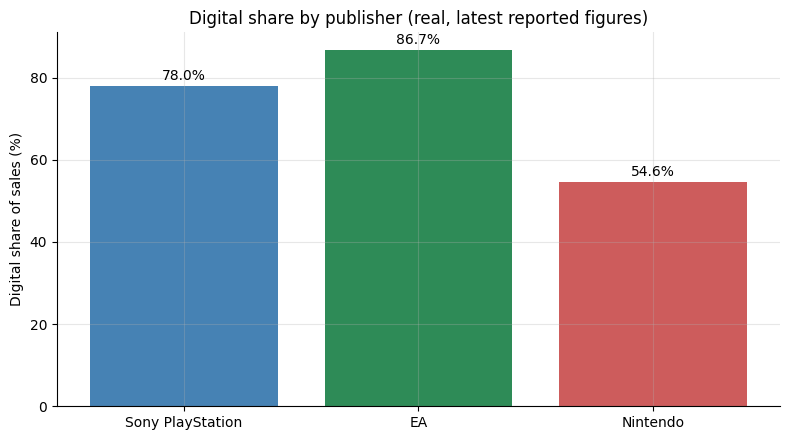

In [16]:
# Cross-publisher comparison -- real data, showing Nintendo is a genuine outlier
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(publisher_digital_share["publisher"], publisher_digital_share["digital_share_pct"],
       color=["steelblue", "seagreen", "indianred"])
ax.set_ylabel("Digital share of sales (%)")
ax.set_title("Digital share by publisher (real, latest reported figures)")
for i, v in enumerate(publisher_digital_share["digital_share_pct"]):
    ax.text(i, v + 1.5, f"{v}%", ha="center")
plt.tight_layout()
plt.show()


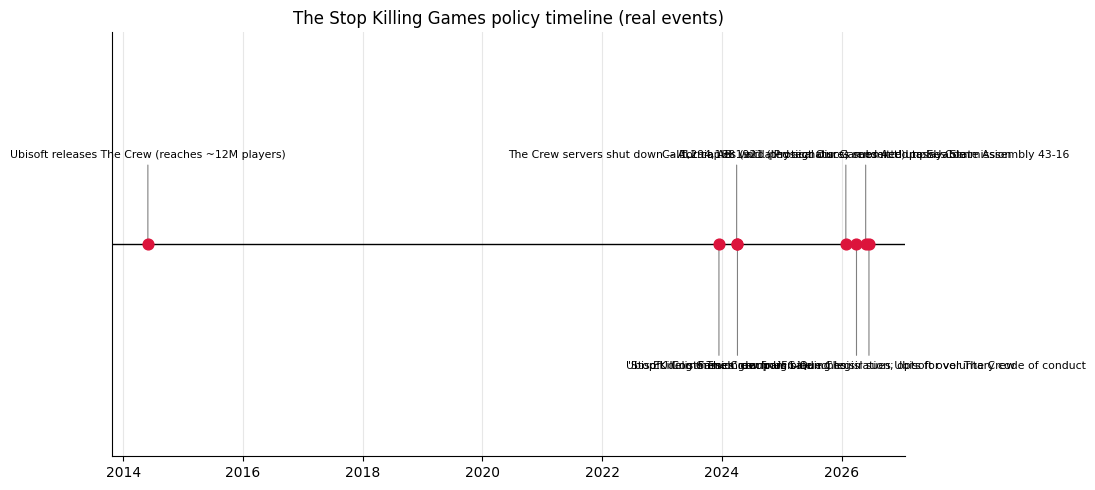

In [17]:
# The REAL policy timeline, plotted as an annotated event chart
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(policy_timeline["date"], [0] * len(policy_timeline), color="crimson", s=60, zorder=5)
for i, row in policy_timeline.iterrows():
    y_offset = 0.4 if i % 2 == 0 else -0.55
    ax.annotate(row["event"], xy=(row["date"], 0), xytext=(row["date"], y_offset),
                fontsize=7.8, ha="center", va="bottom" if y_offset > 0 else "top", rotation=0,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.8))
ax.axhline(0, color="black", lw=1)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_title("The Stop Killing Games policy timeline (real events)")
plt.tight_layout()
plt.show()


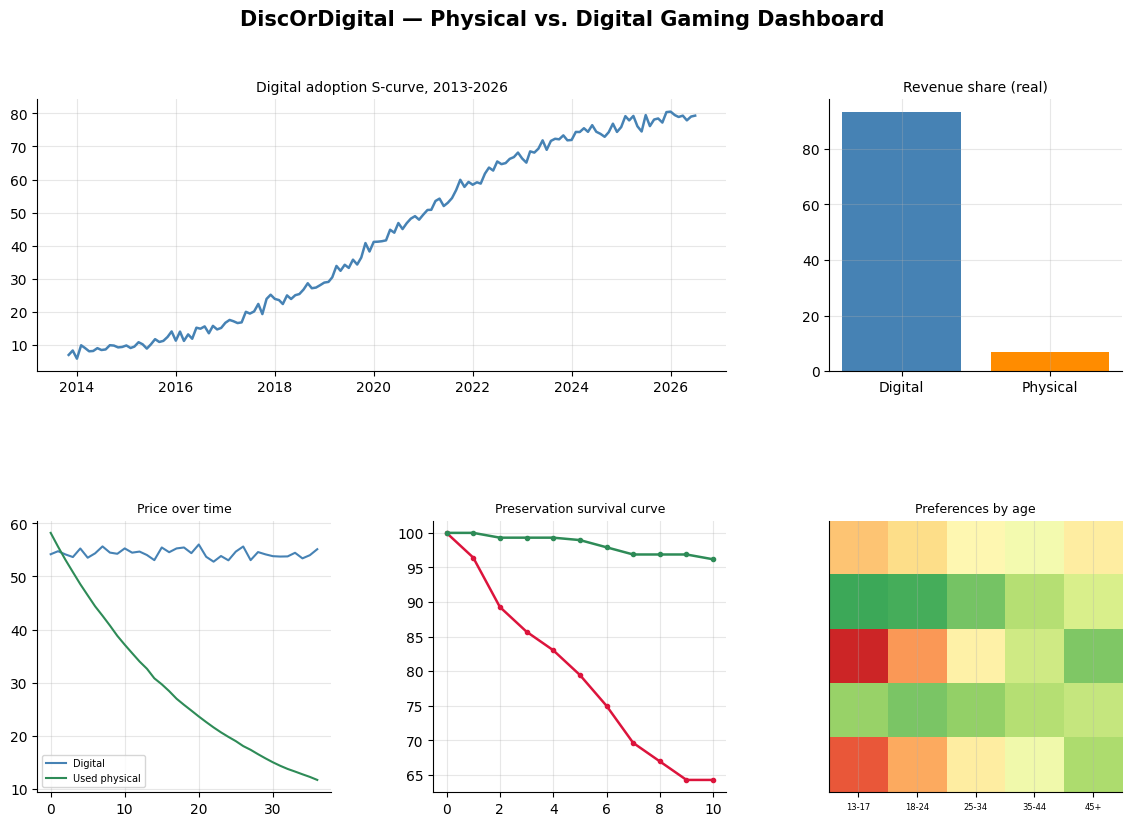

In [18]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.55, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(adoption["month"], adoption["digital_share"] * 100, color="steelblue", lw=1.8)
ax1.set_title("Digital adoption S-curve, 2013-2026", fontsize=10)

ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(revenue_vs_units["format"], revenue_vs_units["revenue_share_pct"], color=["steelblue", "darkorange"])
ax2.set_title("Revenue share (real)", fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(months_since_release, mean_digital, color="steelblue", lw=1.5, label="Digital")
ax3.plot(months_since_release, mean_used_physical, color="seagreen", lw=1.5, label="Used physical")
ax3.set_title("Price over time", fontsize=9); ax3.legend(fontsize=7)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(years, survival_always_online, color="crimson", lw=1.8, marker="o", markersize=3)
ax4.plot(years, survival_offline_capable, color="seagreen", lw=1.8, marker="o", markersize=3)
ax4.set_title("Preservation survival curve", fontsize=9)

ax5 = fig.add_subplot(gs[1, 2])
im = ax5.imshow(pref_summary.values, cmap="RdYlGn", vmin=2, vmax=5, aspect="auto")
ax5.set_xticks(range(len(age_groups))); ax5.set_xticklabels(age_groups, fontsize=6)
ax5.set_yticks([]); ax5.set_title("Preferences by age", fontsize=9)

fig.suptitle("DiscOrDigital — Physical vs. Digital Gaming Dashboard", fontsize=15, fontweight="bold")
plt.show()


## 7. Wrap-up: What This Means for Consumers, Publishers, and Regulators

### What we built
Anchored to **real PlayStation/Nintendo/EA market-share data** and the
**real Stop Killing Games / AB 1921 policy timeline**, we built:

- **pandas**: real-data reference tables, a calibrated long-run digital-
  adoption S-curve validated against two real anchor points, `pivot_table`
  for survey aggregation, and the annotated policy-timeline chart
- **NumPy**: fully vectorized price-depreciation simulation across 150
  titles and 37 months (digital sales sawtooth, physical price-cut steps,
  and exponential used-market decay, each built with broadcasting), and a
  **year-by-year survival-curve simulation** modeling cumulative shutdown
  risk for always-online vs. offline-capable titles across a 400-title
  library and 10-year horizon
- **Visualization**: the adoption S-curve, the value-over-time comparison,
  the preservation survival curve (the core "dilemma" chart), a
  preference heatmap by age group, real revenue-vs-unit-share bars, a
  cross-publisher comparison, an annotated real-event timeline, and a
  one-page dashboard

### The dilemma, made concrete by the data
Section 3 and Section 4 together **are** the trade-off: physical media
depreciates in dollar terms but almost never becomes literally unusable,
while digital is far more convenient and (via sales) often cheaper
up-front — but carries a real, non-trivial, quantifiable risk of total
loss if a title is always-online. The Crew isn't an outlier the data
can't explain; it's a real point sitting almost exactly where the
always-online survival curve predicts.

### Important caveats
- **Individual-title price histories, the preservation-risk simulation,
  and consumer-preference survey data are synthetic**, calibrated to be
  consistent with well-documented real patterns, not drawn from an
  official industry dataset at this granularity.
- The **28% always-online / 5.5% annual hazard rate** parameters in
  Section 4 are illustrative assumptions chosen to be physically
  plausible, not official industry risk statistics (no such published
  dataset currently exists — part of what Stop Killing Games is arguing
  for is *better transparency* on exactly this).
- The **market-share figures, revenue figures, and the entire policy
  timeline are real**, cited to the sources below.
- This notebook does not take a position on whether AB 1921 or similar
  regulation is good policy; it presents the underlying data pattern that
  motivated the debate.

### Sources cited in this notebook
- GameSpot, *"PlayStation Digital Sales Continue To Grow..."*, 2026
- Push Square, coverage of Sony's Q4 FY2025 and Q1 FY2026 financial results, 2026
- Windows Report, *"Sony Set To End Physical PS5 Game Production By 2028"*, 2026
- Niche Gamer, *"Sony: Digital PS5 Software Sales Nets $1.5B..."*, 2026
- Shattered.io / GameDeveloper.com, coverage of The Crew's shutdown, 2024-2026
- Dexerto; TweakTown, *"Stop Killing Games EU Citizens' Initiative"* coverage, 2026
- Tech Insider, *"California AB 1921 'Protect Our Games Act'"* coverage, 2026

### Where to go next
- Replace the synthetic price-tracking data with real historical pricing
  from resale marketplaces (eBay sold listings, PriceCharting) and digital
  storefront sale-history trackers (IsThereAnyDeal, PS Deals).
- Track AB 1921's outcome through the California Senate and Governor's
  desk, and the EU's voluntary code of conduct once published, to see
  whether either policy path actually changes publisher delisting behavior.
- Extend the survival-curve model with REAL historical delisting data
  (VGPC and other preservation trackers maintain public delisting
  databases) rather than illustrative hazard-rate assumptions.
